<a href="https://colab.research.google.com/github/Zer0G0ld/artigo_busca_vetorial_forca_bruta/blob/main/artigo_busca_vetorial_forca_bruta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Instalações e imports
!pip install sentence-transformers numpy matplotlib scikit-learn

import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import time
from sklearn.datasets import fetch_20newsgroups

print("✅ Ambiente pronto!")

✅ Ambiente pronto!


In [4]:
# Baixar títulos de notícias reais
from sklearn.datasets import fetch_20newsgroups

# Baixar notícias (apenas títulos reduzidos)
newsgroups = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))

# Pegar primeiras 5000 notícias
textos = newsgroups.data[:5000]
print(f"Total de textos: {len(textos)}")

# Gerar embeddings
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(textos, show_progress_bar=True)
print(f"Shape dos embeddings: {embeddings.shape}")

Total de textos: 5000


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Shape dos embeddings: (5000, 384)


In [7]:
# Função de busca por força bruta
def brute_force_search(query_vector, vectors, k=5):
    """
    Busca os k vetores mais próximos usando força bruta

    Args:
        query_vector: vetor de consulta (shape: D)
        vectors: matriz de vetores da base (shape: N x D)
        k: número de resultados

    Returns:
        indices: array com os índices dos k mais próximos
        distances: distâncias correspondentes
    """
    # Calcula distância euclidiana para todos os vetores
    distances = np.linalg.norm(vectors - query_vector, axis=1)

    # Pega os k menores índices
    indices = np.argsort(distances)[:k]

    return indices, distances[indices]

# Teste rápido
test_query = embeddings[0]
indices, dists = brute_force_search(test_query, embeddings, k=5)

print(f"Query: {textos[0][:50]}...")
print("\nResultados mais próximos:")
for i, idx in enumerate(indices):
    print(f"{i+1}. {textos[idx][:50]}... (distância: {dists[i]:.4f})")

Query: 

I am sure some bashers of Pens fans are pretty c...

Resultados mais próximos:
1. 

I am sure some bashers of Pens fans are pretty c... (distância: 0.0000)
2. 

Bowman tended to overplay Francis at times becau... (distância: 0.7854)
3. 
   >
   >
   >>Jagr has a higher +/-, but Francis... (distância: 0.8085)
4. Anyone who really believes that the Caps can beat
... (distância: 0.8796)
5. Actually, I was angry when they went away from the... (distância: 0.8862)


N =   100 vetores → 1.06 ms
N =   500 vetores → 0.82 ms
N =  1000 vetores → 2.16 ms
N =  2000 vetores → 2.25 ms
N =  5000 vetores → 4.42 ms


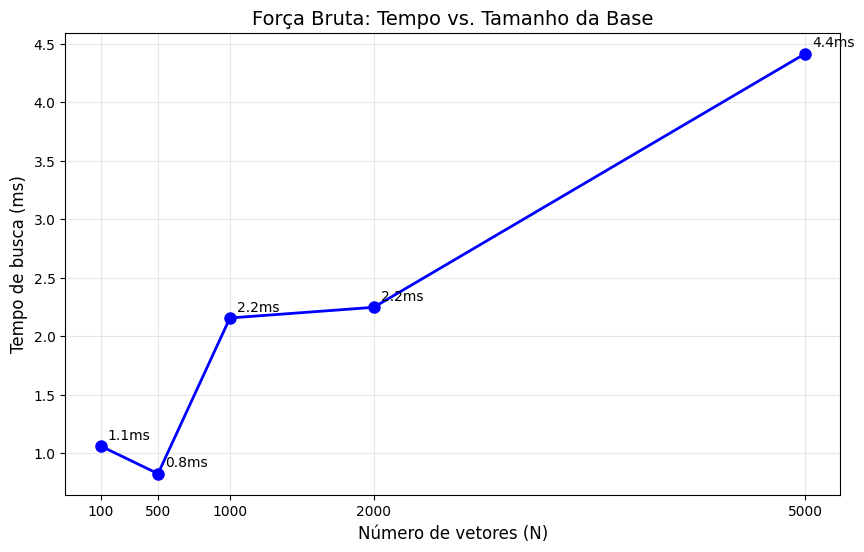

In [8]:
# Experimento de escalabilidade
Ns = [100, 500, 1000, 2000, 5000]
times_ms = []

query = embeddings[0]  # Usa primeiro vetor como consulta

for N in Ns:
    # Pega os primeiros N vetores
    vectors_subset = embeddings[:N]

    # Mede tempo
    start = time.perf_counter()
    indices, _ = brute_force_search(query, vectors_subset, k=5)
    end = time.perf_counter()

    elapsed_ms = (end - start) * 1000
    times_ms.append(elapsed_ms)

    print(f"N = {N:5d} vetores → {elapsed_ms:.2f} ms")

# Gráfico
plt.figure(figsize=(10, 6))
plt.plot(Ns, times_ms, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Número de vetores (N)', fontsize=12)
plt.ylabel('Tempo de busca (ms)', fontsize=12)
plt.title('Força Bruta: Tempo vs. Tamanho da Base', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(Ns)

# Adiciona anotações
for i, (N, t) in enumerate(zip(Ns, times_ms)):
    plt.annotate(f'{t:.1f}ms', (N, t), xytext=(5, 5), textcoords='offset points')

plt.show()

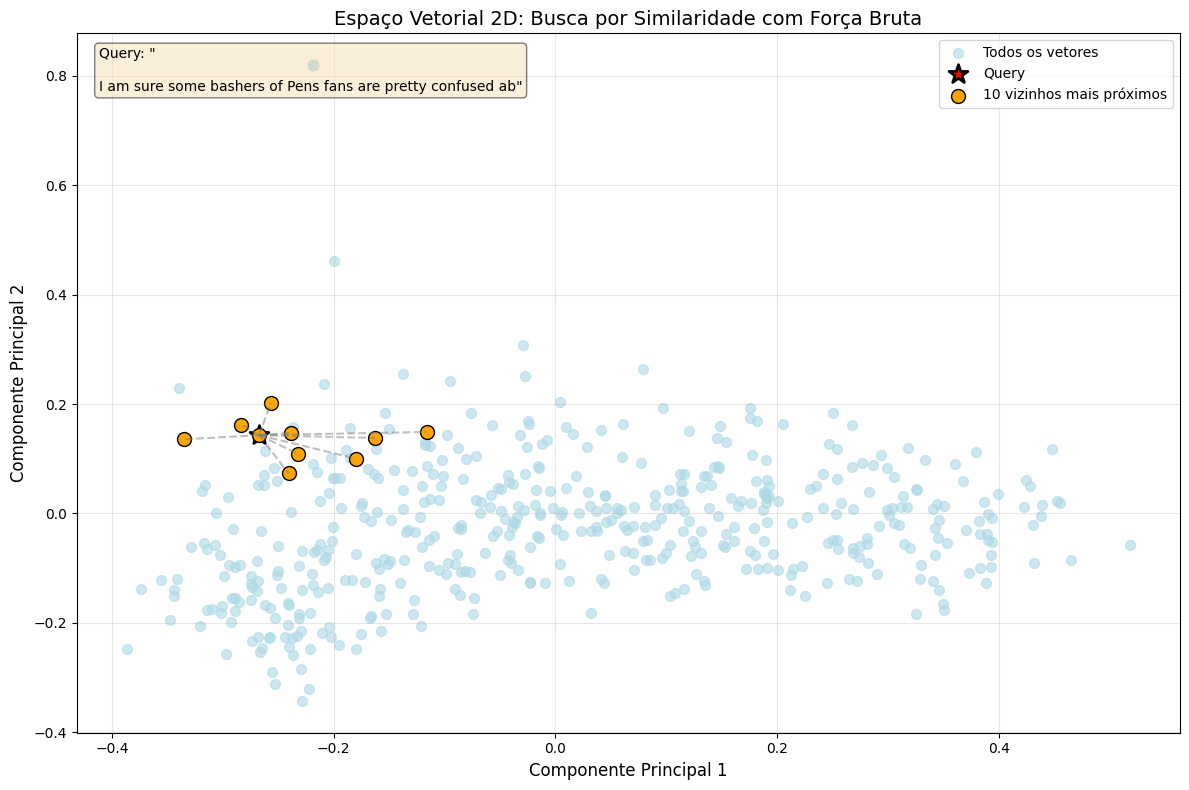

In [12]:
# Projetar embeddings em 2D
from sklearn.decomposition import PCA

# Reduzir para 2D (usando um subconjunto para não ficar lento)
n_viz = 500  # Número de pontos para visualizar
embeddings_subset = embeddings[:n_viz]
frases_subset = textos[:n_viz]

pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings_subset)

# Escolher um ponto como query (ex: índice 0)
query_idx = 0
query_2d = embeddings_2d[query_idx:query_idx+1]

# Encontrar vizinhos via força bruta
query_vector = embeddings_subset[query_idx]
viz_indices, _ = brute_force_search(query_vector, embeddings_subset, k=10)

# Plot
plt.figure(figsize=(12, 8))

# Todos os pontos
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
           c='lightblue', alpha=0.6, s=50, label='Todos os vetores')

# Query em destaque
plt.scatter(query_2d[:, 0], query_2d[:, 1],
           c='red', s=200, marker='*', label='Query', edgecolors='black', linewidth=2)

# Vizinhos mais próximos
vizinhos_2d = embeddings_2d[viz_indices]
plt.scatter(vizinhos_2d[:, 0], vizinhos_2d[:, 1],
           c='orange', s=100, label=f'{len(viz_indices)} vizinhos mais próximos',
           edgecolors='black', linewidth=1)

# Linhas conectando query aos vizinhos
for viz in vizinhos_2d:
    plt.plot([query_2d[0, 0], viz[0]], [query_2d[0, 1], viz[1]],
            'gray', linestyle='--', alpha=0.5)

plt.xlabel('Componente Principal 1', fontsize=12)
plt.ylabel('Componente Principal 2', fontsize=12)
plt.title('Espaço Vetorial 2D: Busca por Similaridade com Força Bruta', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

# Mostrar frase da query
plt.text(0.02, 0.98, f'Query: "{frases_subset[query_idx][:60]}"',
         transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


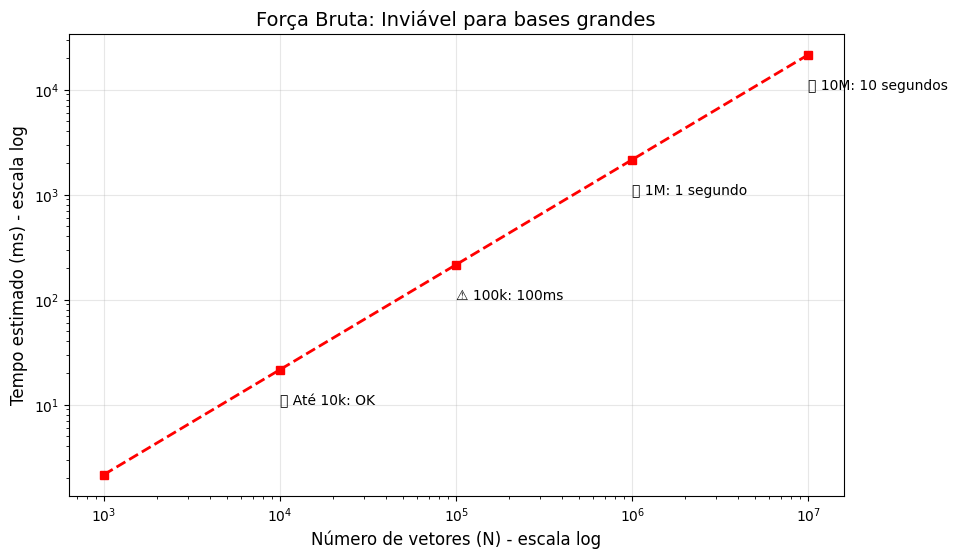


📊 Tabela de escalabilidade:
| N vetores | Tempo estimado | Viabilidade |
|-----------|----------------|-------------|
|     1,000 |            2 ms | ✅ |
|    10,000 |           22 ms | ✅ |
|   100,000 |          216 ms | ⚠️ |
| 1,000,000 |         2156 ms | ❌ |
| 10,000,000 |        21557 ms | ❌ |


In [13]:
# Projeção para bases maiores
Ns_teorico = [1000, 10000, 100000, 1000000, 10000000]
tempo_base = times_ms[2]  # tempo para N=1000
tempo_estimado = [tempo_base * (N/1000) for N in Ns_teorico]

plt.figure(figsize=(10, 6))
plt.plot(Ns_teorico, tempo_estimado, 'r--', linewidth=2, marker='s')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Número de vetores (N) - escala log', fontsize=12)
plt.ylabel('Tempo estimado (ms) - escala log', fontsize=12)
plt.title('Força Bruta: Inviável para bases grandes', fontsize=14)
plt.grid(True, alpha=0.3)

# Anotações
plt.annotate('✅ Até 10k: OK', xy=(10000, 10), fontsize=10)
plt.annotate('⚠️ 100k: 100ms', xy=(100000, 100), fontsize=10)
plt.annotate('❌ 1M: 1 segundo', xy=(1000000, 1000), fontsize=10)
plt.annotate('🚨 10M: 10 segundos', xy=(10000000, 10000), fontsize=10)

plt.show()

print("\n📊 Tabela de escalabilidade:")
print("| N vetores | Tempo estimado | Viabilidade |")
print("|-----------|----------------|-------------|")
for N, t in zip(Ns_teorico, tempo_estimado):
    status = "✅" if N <= 10000 else "⚠️" if N <= 100000 else "❌"
    print(f"| {N:9,} | {t:12.0f} ms | {status} |")

In [14]:
# Usando NearestNeighbors do sklearn
from sklearn.neighbors import NearestNeighbors

# Força bruta via sklearn (mas com otimizações em C)
nn = NearestNeighbors(n_neighbors=5, algorithm='brute', metric='euclidean')
nn.fit(embeddings[:5000])

start = time.perf_counter()
distances, indices = nn.kneighbors(embeddings[0:1])
end = time.perf_counter()

print(f"Sklearn (C optimizado): {(end-start)*1000:.2f} ms")
print(f"Nosso numpy: {times_ms[-1]:.2f} ms")
print("→ O numpy já é bem rápido! O gargalo é O(N), não a linguagem.")

Sklearn (C optimizado): 231.11 ms
Nosso numpy: 4.42 ms
→ O numpy já é bem rápido! O gargalo é O(N), não a linguagem.


In [16]:
# Salvar embeddings para reutilizar
import pickle

# Salvar em arquivo
with open('embeddings_5000.pkl', 'wb') as f:
    pickle.dump({
        'embeddings': embeddings,
        'frases': textos,
        'model_name': 'all-MiniLM-L6-v2'
    }, f)

print("✅ Embeddings salvos! Baixe o arquivo em:")
print("Arquivo → Download → embeddings_5000.pkl")

# Ou salvar no Google Drive (se preferir)
from google.colab import drive
drive.mount('/content/drive')
with open('/content/drive/MyDrive/embeddings_5000.pkl', 'wb') as f:
    pickle.dump({'embeddings': embeddings, 'frases': textos}, f)
print("✅ Salvo no Google Drive!")

✅ Embeddings salvos! Baixe o arquivo em:
Arquivo → Download → embeddings_5000.pkl
Mounted at /content/drive
✅ Salvo no Google Drive!
